In [ ]:
import json, cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
RUN_NAME = "run_experiment_01"
LOG_JSON_PATH = f"{RUN_NAME}.json"
leftPath = "images/izq.png"
rightPath = "images/der.png"
logs = {}

In [3]:
def addLog(section, key, value):
    global logs
    if section not in logs:
        logs[section] = {}
    logs[section][key] = value

def saveLogsAsJSON(logsDict, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(logsDict, f, indent=4, ensure_ascii=False)
    print(f"Logs guardados en: {filename}")


In [4]:
def loadImages(leftPath, rightPath):
    imgLeft = cv2.imread(leftPath)
    imgRight = cv2.imread(rightPath)

    if imgLeft is None or imgRight is None:
        raise ValueError("No se pudieron cargar las imágenes")

    return imgLeft, imgRight

In [5]:
def convertToGray(imgLeft, imgRight):
    grayLeft = cv2.cvtColor(imgLeft, cv2.COLOR_BGR2GRAY)
    grayRight = cv2.cvtColor(imgRight, cv2.COLOR_BGR2GRAY)
    return grayLeft, grayRight

In [6]:
def detectWithSift(grayLeft, grayRight, nFeatures=2000):

    # left se queda fija y right se va a transformar para acoplar con left
    sift = cv2.SIFT_create(nfeatures=nFeatures)

    kpLeft, desLeft = sift.detectAndCompute(grayLeft, None)   # Train (destino)
    kpRight, desRight = sift.detectAndCompute(grayRight, None)  # Query (se transforma)

    addLog("features", "kp_left", len(kpLeft))
    addLog("features", "kp_right", len(kpRight))

    return kpLeft, desLeft, kpRight, desRight

In [7]:
def matchWithFlann(desRight, desLeft, ratio=0.7):

    # FLANN KDTree para SIFT
    FLANN_INDEX_KDTREE = 1
    indexParams = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    searchParams = dict(checks=50)

    flann = cv2.FlannBasedMatcher(indexParams, searchParams)

    # derecha = query, izquierda = train
    matches = flann.knnMatch(desRight, desLeft, k=2)

    # muchos ruido asi que filtramos con lowe ratio test
    goodMatches = []

    for m, n in matches:
        if m.distance < ratio * n.distance:
            goodMatches.append(m)

    addLog("matching", "good_matches", len(goodMatches))

    return goodMatches

In [8]:
def drawMatchesImage(grayRight, kpRight, grayLeft, kpLeft, goodMatches):

    imgMatches = cv2.drawMatches(
        grayRight, kpRight,
        grayLeft, kpLeft,
        goodMatches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16,8))
    plt.imshow(imgMatches, cmap="gray")
    plt.axis("off")
    plt.show()

In [9]:
def computeHomography(kpRight, kpLeft, goodMatches):

    # extraer coordenadas x,y
    srcPts = np.float32([kpRight[m.queryIdx].pt for m in goodMatches]).reshape(-1,1,2)
    dstPts = np.float32([kpLeft[m.trainIdx].pt for m in goodMatches]).reshape(-1,1,2)

    M, mask = cv2.findHomography(srcPts, dstPts, cv2.RANSAC, 5.0)

    addLog("homography", "inliers", int(mask.sum()) if mask is not None else 0)

    return M

In [10]:
def warpAndBlend(imgLeft, imgRight, M):

    # warp = deformación para calcular nuestro canvas / lienzo

    hLeft, wLeft = imgLeft.shape[:2]
    hRight, wRight = imgRight.shape[:2]

    # ancho = suma de anchos
    # alto = el mayor
    canvasW = wLeft + wRight
    canvasH = max(hLeft, hRight)

    # la derecha se movera hacia coordenadas positivas
    panorama = cv2.warpPerspective(imgRight, M, (canvasW, canvasH))

    # colocar izquierda en el canvas
    panorama[0:hLeft, 0:wLeft] = imgLeft

    # convertir a gris para encontrar zonas negras
    panoramaGray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)

    _, maskContent = cv2.threshold(panoramaGray, 1, 255, cv2.THRESH_BINARY)
    maskInv = cv2.bitwise_not(maskContent)

    leftOnCanvas = np.zeros_like(panorama)
    leftOnCanvas[0:hLeft, 0:wLeft] = imgLeft

    imgLeftPart = cv2.bitwise_and(leftOnCanvas, leftOnCanvas, mask=maskInv)
    imgRightPart = cv2.bitwise_and(panorama, panorama, mask=maskContent)

    result = cv2.add(imgLeftPart, imgRightPart)

    return result

In [11]:
def cropBlackBorders(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > 0)

    if len(xs) == 0 or len(ys) == 0:
        return img

    xMin, xMax = xs.min(), xs.max()
    yMin, yMax = ys.min(), ys.max()

    return img[yMin:yMax+1, xMin:xMax+1]

In [12]:
def stitchPanorama(leftPath, rightPath):

    imgLeft, imgRight = loadImages(leftPath, rightPath)
    grayLeft, grayRight = convertToGray(imgLeft, imgRight)

    kpLeft, desLeft, kpRight, desRight = detectWithSift(grayLeft, grayRight)

    goodMatches = matchWithFlann(desRight, desLeft)

    drawMatchesImage(grayRight, kpRight, grayLeft, kpLeft, goodMatches)

    M = computeHomography(kpRight, kpLeft, goodMatches)

    panorama = warpAndBlend(imgLeft, imgRight, M)

    panorama = cropBlackBorders(panorama)

    panoramaRgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16,8))
    plt.imshow(panoramaRgb)
    plt.axis("off")
    plt.show()

    return panorama

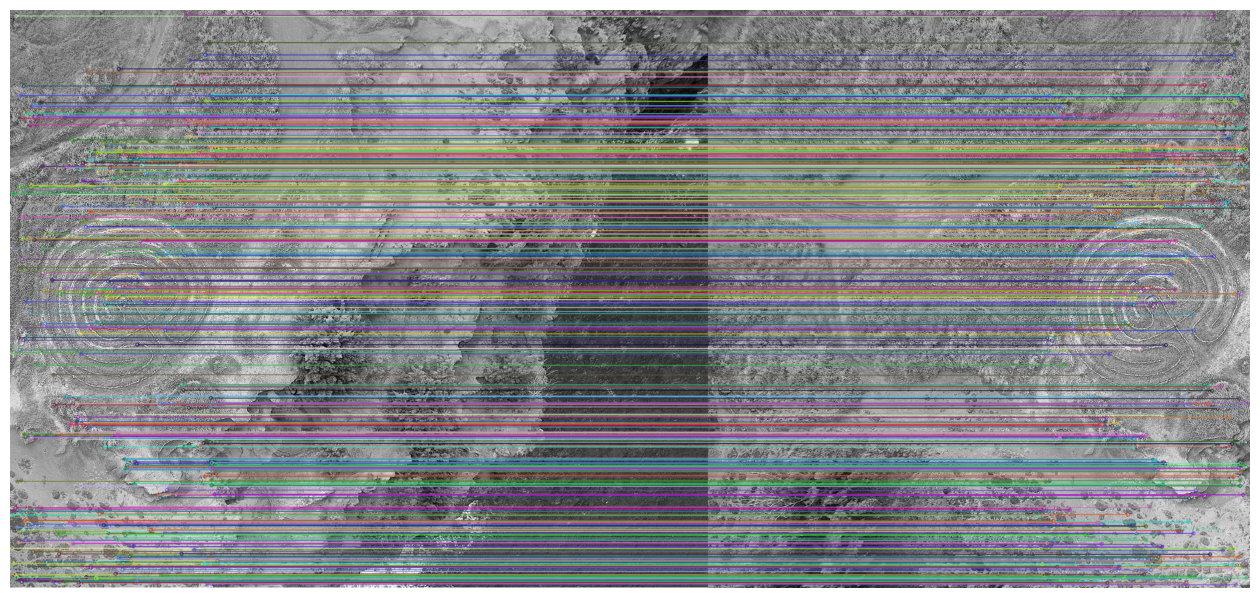

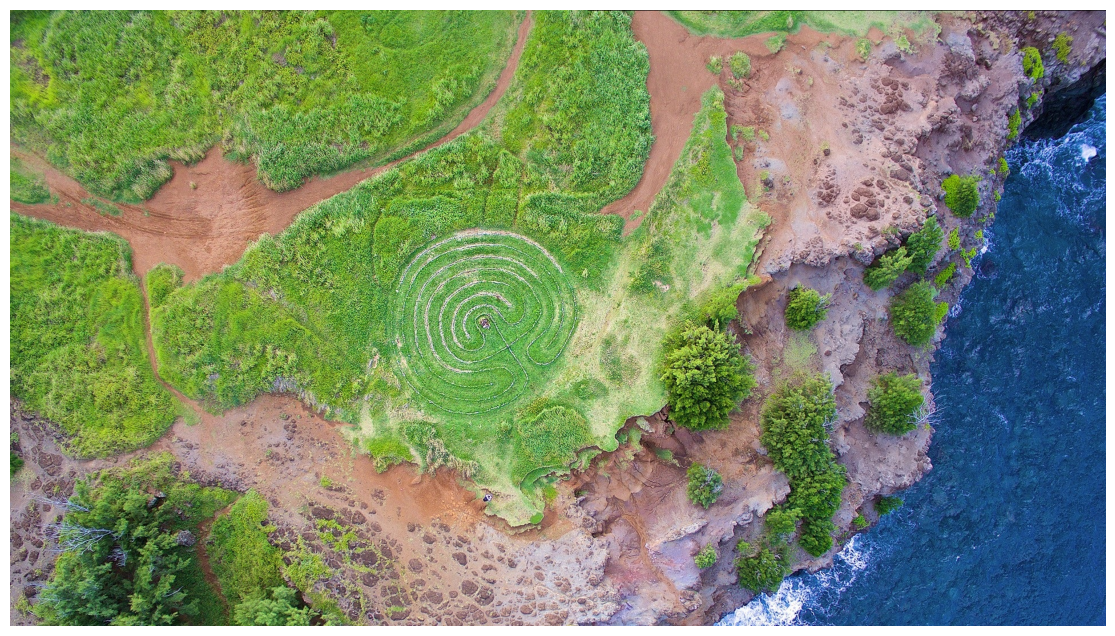

Logs guardados en: run_experiment_01.json


In [13]:
panorama = stitchPanorama(leftPath, rightPath)

saveLogsAsJSON(logs, LOG_JSON_PATH)